# Model Training and SHAP Analysis

In [1]:
import os
import hopsworks
import pandas as pd
import joblib
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Reading the data from Hopsworks

In [2]:
# 1. Load your API key
load_dotenv()
api_key = os.getenv("HopsworkAPI_KEY")

project = hopsworks.login(api_key_value=api_key)

fs = project.get_feature_store()

fg = fs.get_feature_group("sialkot_aqi_features_v2", version=1)
df = fg.read()

2026-06-07 19:23:04,041 INFO: Initializing external client
2026-06-07 19:23:04,041 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-06-07 19:23:07,408 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32895
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (7.09s) 


In [3]:
df.head(10)

,datetime,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,aqi,co,no2,o3,so2,pm2_5,pm10,nh3,date,hour,city
0,2026-06-07 11:00:00,16.9,0.0,37.1,29.5,5.67,18,4,270.45,2.31,172.95,9.52,40.62,60.04,19.23,2026-06-07,11,Sialkot
1,2026-06-07 12:00:00,17.1,0.0,36.5,29.5,5.40,19,4,285.89,3.40,171.28,10.20,41.18,60.45,22.62,2026-06-07,12,Sialkot
2,2026-02-01 00:00:00,0.6,0.0,9.3,2.5,0.00,100,5,2435.33,24.59,4.33,1.30,346.10,375.74,5.82,2026-02-01,0,Sialkot
3,2026-02-01 01:00:00,8.6,0.0,9.4,10.8,0.04,97,5,2413.72,23.49,3.61,1.26,353.64,377.72,12.67,2026-02-01,1,Sialkot
4,2026-02-01 02:00:00,3.3,0.0,8.4,9.0,0.00,100,5,2466.80,23.53,2.63,1.66,365.58,389.49,15.17,2026-02-01,2,Sialkot
5,2026-02-01 03:00:00,5.2,0.0,9.4,10.1,0.04,97,5,2593.56,24.47,2.44,2.10,379.25,404.59,15.36,2026-02-01,3,Sialkot
6,2026-02-01 04:00:00,7.4,0.0,12.4,10.8,0.12,92,5,2658.71,22.94,8.73,2.35,382.61,412.41,14.31,2026-02-01,4,Sialkot
7,2026-02-01 05:00:00,9.6,0.0,14.8,13.3,0.33,80,5,2612.46,21.51,22.83,2.66,378.08,413.17,16.70,2026-02-01,5,Sialkot
8,2026-02-01 06:00:00,5.2,0.0,15.8,19.8,0.52,72,5,2537.78,20.88,53.49,3.07,380.16,416.14,22.43,2026-02-01,6,Sialkot
9,2026-02-01 07:00:00,5.4,0.0,16.7,15.5,0.70,64,5,843.28,5.51,151.99,9.36,149.55,161.54,4.34,2026-02-01,7,Sialkot


# Feature Engineering 

In [4]:
# Have access to future weather via Open-Meteo!
df['temp_lag1'] = df['apparent_temperature'].shift(1)
df['wind_rolling_6'] = df['wind_speed_100m'].rolling(6).mean()

In [5]:
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month']       = df['datetime'].dt.month
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

In [6]:
import numpy as np

# Convert the 24-hour clock into a mathematical circle using Sine and Cosine
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

In [7]:
# You can now safely drop the raw 'hour' column
df = df.drop(columns=['hour'])

In [8]:
df = df.dropna().reset_index(drop=True)

In [9]:
print("🔪 Preparing data and splitting features...")
df = df.sort_values('datetime').reset_index(drop=True)

# We drop columns that leak the answer, or that math can't understand
columns_to_drop = ['city', 'date', 'datetime', 'aqi', 'pm2_5', 'pm10']

# TODO: Create your 'X' dataframe by dropping the columns above
X = df.drop(columns=columns_to_drop)

# TODO: Create your 'y' series using ONLY the 'pm2_5' column
y = df['pm2_5']

🔪 Preparing data and splitting features...


# Chronological Splitting the data

In [10]:
# TODO: Use train_test_split to hide 20% of the data. Set random_state=42 for reproducibility.
# CORRECT FOR TIME SERIES (Chronological Cut)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [11]:
X_train

,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,co,no2,o3,so2,nh3,temp_lag1,wind_rolling_6,day_of_week,month,is_weekend,hour_sin,hour_cos
0,5.2,0.0,9.4,10.1,0.04,97,2593.56,24.47,2.44,2.10,15.36,8.4,8.616667,6,2,1,0.707107,7.071068e-01
1,7.4,0.0,12.4,10.8,0.12,92,2658.71,22.94,8.73,2.35,14.31,9.4,7.033333,6,2,1,0.866025,5.000000e-01
2,9.6,0.0,14.8,13.3,0.33,80,2612.46,21.51,22.83,2.66,16.70,12.4,5.783333,6,2,1,0.965926,2.588190e-01
3,5.2,0.0,15.8,19.8,0.52,72,2537.78,20.88,53.49,3.07,22.43,14.8,6.550000,6,2,1,1.000000,6.123234e-17
4,5.4,0.0,16.7,15.5,0.70,64,843.28,5.51,151.99,9.36,4.34,15.8,6.016667,6,2,1,0.965926,-2.588190e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2234,13.7,0.0,32.3,29.5,3.02,36,578.91,4.86,168.52,12.33,44.70,29.9,14.766667,1,5,0,0.965926,2.588190e-01
2235,6.6,0.0,34.1,25.9,2.87,39,544.30,3.47,188.76,12.99,42.93,32.3,11.133333,1,5,0,1.000000,6.123234e-17
2236,1.4,0.0,36.6,19.1,3.21,36,444.13,2.26,188.35,12.55,34.64,34.1,11.016667,1,5,0,0.965926,-2.588190e-01
2237,6.6,0.0,34.7,16.9,3.29,35,368.42,1.93,175.64,10.24,27.18,36.6,9.016667,1,5,0,0.866025,-5.000000e-01


In [12]:
y_train

0       379.25
1       382.61
2       378.08
3       380.16
4       149.55
         ...  
2234     67.18
2235     71.49
2236     67.20
2237     58.23
2238     53.25
Name: pm2_5, Length: 2239, dtype: float64

In [13]:
X.head(5)

,wind_speed_100m,precipitation,apparent_temperature,wind_gusts_10m,vapour_pressure_deficit,relative_humidity_2m,co,no2,o3,so2,nh3,temp_lag1,wind_rolling_6,day_of_week,month,is_weekend,hour_sin,hour_cos
0,5.2,0.0,9.4,10.1,0.04,97,2593.56,24.47,2.44,2.10,15.36,8.4,8.616667,6,2,1,0.707107,7.071068e-01
1,7.4,0.0,12.4,10.8,0.12,92,2658.71,22.94,8.73,2.35,14.31,9.4,7.033333,6,2,1,0.866025,5.000000e-01
2,9.6,0.0,14.8,13.3,0.33,80,2612.46,21.51,22.83,2.66,16.70,12.4,5.783333,6,2,1,0.965926,2.588190e-01
3,5.2,0.0,15.8,19.8,0.52,72,2537.78,20.88,53.49,3.07,22.43,14.8,6.550000,6,2,1,1.000000,6.123234e-17
4,5.4,0.0,16.7,15.5,0.70,64,843.28,5.51,151.99,9.36,4.34,15.8,6.016667,6,2,1,0.965926,-2.588190e-01


# Initialize the models

In [14]:
# Initialize the competitors
models = {
    "Ridge_Regression": Ridge(),
    "Random_Forest": RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42),
    "XGBoost": XGBRegressor(learning_rate=0.1, max_depth=6, n_estimators=200, random_state=42)
}

In [15]:
results = {}

# Train and evaluate each model in a loop
for name, model in models.items():
    # TODO: Train the model using the .fit() method on your training data
    model.fit(X_train, y_train)
    
    # TODO: Ask the model to predict PM2.5 for the hidden X_test data
    predictions = model.predict(X_test)
    
    # TODO: Calculate the three required metrics by comparing 'predictions' to 'y_test'
    rmse = root_mean_squared_error(y_test, predictions) 
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2, "model_object": model}
    print(f"✅ {name} trained. R2 Score: {r2:.3f}")

✅ Ridge_Regression trained. R2 Score: 0.603
✅ Random_Forest trained. R2 Score: 0.622
✅ XGBoost trained. R2 Score: 0.634


# Model Performance

In [16]:
results['Ridge_Regression']

{'RMSE': 17.4913557538891,
 'MAE': 13.679671248218392,
 'R2': 0.6026434794849225,
 'model_object': Ridge()}

In [17]:
results['Random_Forest']

{'RMSE': 17.050438467866297,
 'MAE': 12.19818172899026,
 'R2': 0.6224238952751939,
 'model_object': RandomForestRegressor(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)}

In [18]:
results['XGBoost']

{'RMSE': 16.784109830745116,
 'MAE': 12.543842552321296,
 'R2': 0.6341272844733064,
 'model_object': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)}

In [19]:
best_model_name = max(results, key=lambda k: results[k]['R2'])
best_metrics = results[best_model_name]
champion_model = best_metrics['model_object']

print(f"\n🏆 WINNER: {best_model_name} with an R2 of {best_metrics['R2']:.3f}")


🏆 WINNER: XGBoost with an R2 of 0.634


# SHAP-Based feature importance

In [25]:
model = champion_model

In [26]:
import shap
import matplotlib.pyplot as plt

In [30]:
# 1. Initialize JS visualization for the notebook
shap.initjs()

# 2. Create the SHAP Explainer specific to tree-based models (Random Forest)
explainer = shap.TreeExplainer(model)

# 3. Calculate SHAP values for your testing data
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values calculated successfully!")

✅ SHAP values calculated successfully!


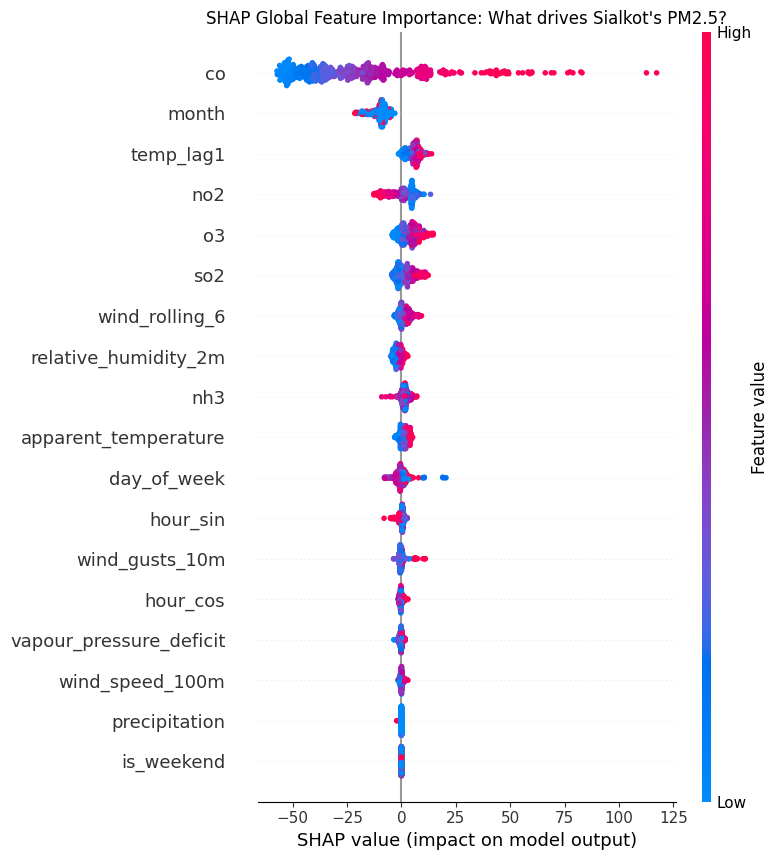

In [31]:
# Plot the global summary (Beeswarm plot)
plt.title("SHAP Global Feature Importance: What drives Sialkot's PM2.5?")
shap.summary_plot(shap_values, X_test)

In [32]:
# Explain the very first prediction in your test set (Hour 0)
# This creates an interactive HTML plot right in your notebook!
shap.force_plot(
    explainer.expected_value[0] if isinstance(explainer.expected_value, list) else explainer.expected_value, 
    shap_values[0], 
    X_test.iloc[0, :]
)